In [107]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import seaborn as sns

In [3]:
# database connection
conn=sqlite3.connect('customer_churn.db')

sql_query= """
             select name
             from sqlite_master
             where type ='table';        
        """
table = pd.read_sql(sql_query,conn)

# create dataframe for each table
for table_name in table['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"created datarame:df_{table_name}")
conn.close()    

created datarame:df_db_customer
created datarame:df_db_subscription
created datarame:df_db_support


***DATA CLEANING***

In [4]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [5]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [6]:
#1.rename name to cust_name
#2.change date datatype
#3.drop col-interest and pincode
#4.gender data standardization 
#5.fill country missing data

In [7]:
#1.rename name to cust_name
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)

In [8]:
df_db_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode'],
      dtype='str')

In [9]:
#3.drop col-interest and pincode
df_db_customer.drop(columns=['interests','pincode'],inplace=True)

In [10]:
df_db_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob'], dtype='str')

In [11]:
#2.change date datatype
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [12]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [13]:
#4.gender data standardization 
df_db_customer['gender']=df_db_customer['gender'].replace({ 'Men':'Male','Women':'Female'})

In [14]:
df_db_customer.tail()

,customerid,customer_name,country,state,gender,dob
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Male,1991-05-14
20,0023-UYUPN,sudevi,India,Maharashtra,Female,1977-10-06


In [15]:
#5.fill country missing data
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [16]:
#country state unique key value pair
state_country_map=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_map))

In [17]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [18]:
df_db_subscription.head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [19]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [20]:
date_col=['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [21]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [22]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [23]:
df_db_support.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score'], dtype='str')

In [24]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [25]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


***FEATURE ENGINEERING***

In [26]:
#create new col using existing col-churn_flag
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [27]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [28]:
#first remove deplicate then merge
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [29]:
df.shape

(23, 20)

In [30]:
df_db_subscription['customerid'].nunique()

21

In [31]:
df_db_support['customerid'].nunique()

7

In [32]:
df_db_support['customerid'].size


9

In [33]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [34]:
df_db_support['complain_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [35]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [36]:
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN


In [37]:
df.shape

(21, 21)

***data analysis***

In [38]:
df.to_csv('exported_churn.csv',index=False)

In [39]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='str')

In [40]:
#1.churn rate
churn_rate=df['churn_flag'].mean()*100
print("churn_rate =", round(churn_rate,2),"%")


churn_rate = 28.57 %


In [41]:
#2.Retention Rate
retention_rate=100-churn_rate
print("retention_rate =", round(retention_rate,2), "%")


retention_rate = 71.43 %


In [42]:
#3.churn by plan type
churn_by_plan=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
churn_by_plan

,plan_type,churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [43]:
#4.churn_by_state
churn_by_state=df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='state_churn_pct')
churn_by_state

,state,state_churn_pct
0,Delhi,25.00
1,Karnataka,100.00
2,Kathmandu,0.00
3,Maharashtra,0.00
4,Meghalaya,66.67
5,Nagaland,0.00
6,Rajasthan,0.00
7,Telangana,50.00
8,Uttar Pradesh,0.00


In [44]:
#5.churn_by_subscription_type
churn_by_subscription_type=df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct')
churn_by_subscription_type

,subscription_type,churn_rate_pct
0,Organic,0.00
1,Paid,16.67
2,Refferal,83.33


In [45]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='str')

In [46]:
#6.arpu-avg revenue per userr
arpu=df['monthly_charges'].mean()
print("ARPU = ", round(arpu,2))

ARPU =  18.85


In [47]:
#7.avg tenure
today=pd.Timestamp.today()
df['avg_tenure']=np.where( 
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
      (today-df['subscription_start_date']).dt.days
)                      
avg_tenure=df['avg_tenure'].mean ()
print("avg_tenure",round(avg_tenure,0),"days")

avg_tenure 1528.0 days


In [48]:
#8.revenue at risk-revenue lost from churned users
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("revenue_at_risk (Rs 'K')=", revenue_at_risk)

revenue_at_risk (Rs 'K')= 73.94


In [51]:
#9.escalations_rate
escalations_rate=(df['escalations']=='Y').mean()*100
print("escalations_rate = ",round(escalations_rate,2),"%")

escalations_rate =  19.05 %


In [52]:
#10.avg complain per user
avg_complain=df['complain_count'].sum()/df['customerid'].nunique()
print("avg_complain_per_user = " ,round(avg_complain,2))

avg_complain_per_user =  0.43


In [71]:
#11.correlation escalation vs churn
df['escalations']=np.where(df['escalations']=='Y',1,0)
corr_df = df[['escalations', 'churn_flag']].dropna()
correlation = corr_df['escalations'].corr(corr_df['churn_flag'])
print("Correlation b/w escalation vs churn =", round(correlation, 2))

In [74]:
#12.chrun_risk-create col using existing col
condition=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
choices=['low','med','high']
df['churn_risk']=np.select(condition,choices,default='unknown')
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count,avg_tenure,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1994.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1379.0,low


***data visualization using matplotlib***

In [75]:
df_visual=df.copy()
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count,avg_tenure,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1994.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1379.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2669.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,0,20.0,1.0,419.0,high


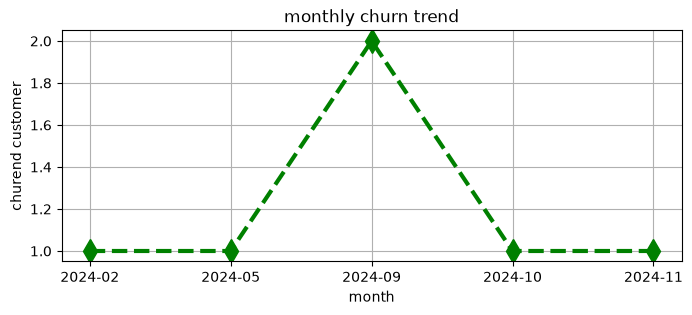

In [84]:
#monthly churn_trend
df_visual['cancellation_Month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_Month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,marker='d',linestyle='dashed',color='green',markersize=12,linewidth=3)
plt.title('monthly churn trend')
plt.xlabel('month')
plt.ylabel('churend customer')
plt.grid()
plt.show()

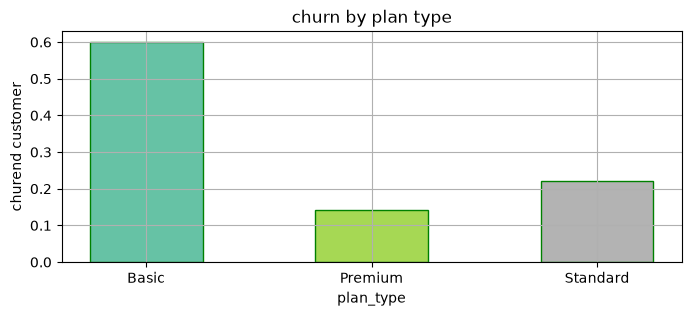

In [95]:
#churn_plan_type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(8,3))
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.bar(churn_plan.index,churn_plan.values,color=colors,edgecolor='green',width=0.5)
plt.title('churn by plan type')
plt.xlabel('plan_type')
plt.ylabel('churend customer')
plt.grid()
plt.show()

In [ ]:
#churn by state


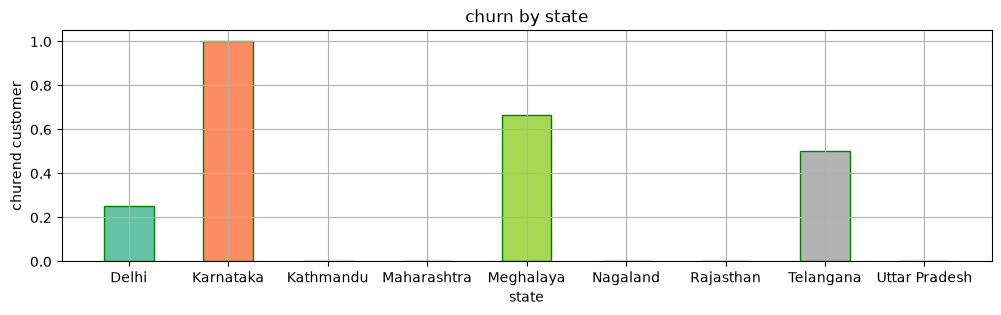

In [102]:
statewise_churn=df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(12,3))
colors=plt.cm.Set2(np.linspace(0,1,len(statewise_churn)))
plt.bar(statewise_churn.index,statewise_churn.values,color=colors,edgecolor='green',width=0.5)
plt.title('churn by state')
plt.xlabel('state')
plt.ylabel('churend customer')
plt.grid()
plt.show()

***data visualization using seaborn***

df_visual.columns

In [110]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk']].head(5)

,plan_type,contract_type,churn_score,churn_flag,churn_risk
0,Standard,Annual,12,0,low
1,Premium,Annual,91,1,high
2,Basic,Monthly,34,0,low
3,Premium,Annual,8,0,low
4,Standard,Monthly,88,1,high


In [116]:
df_encoded = df_visual[
    ['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk',]]
cat_col = ['plan_type', 'contract_type', 'churn_risk']
for col in cat_col:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

In [117]:
df_encoded.head(3)

,plan_type,contract_type,churn_score,churn_flag,churn_risk
0,2,0,12,0,1
1,1,0,91,1,0
2,0,1,34,0,1


<Axes: >

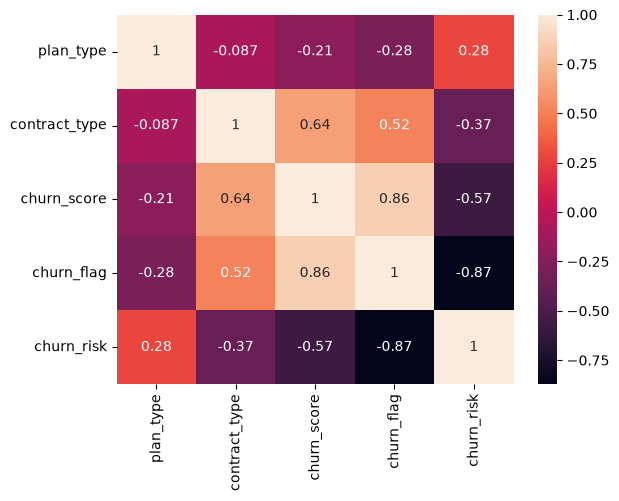

In [118]:
#heatmap
sns.heatmap(df_encoded.corr(),annot=True)

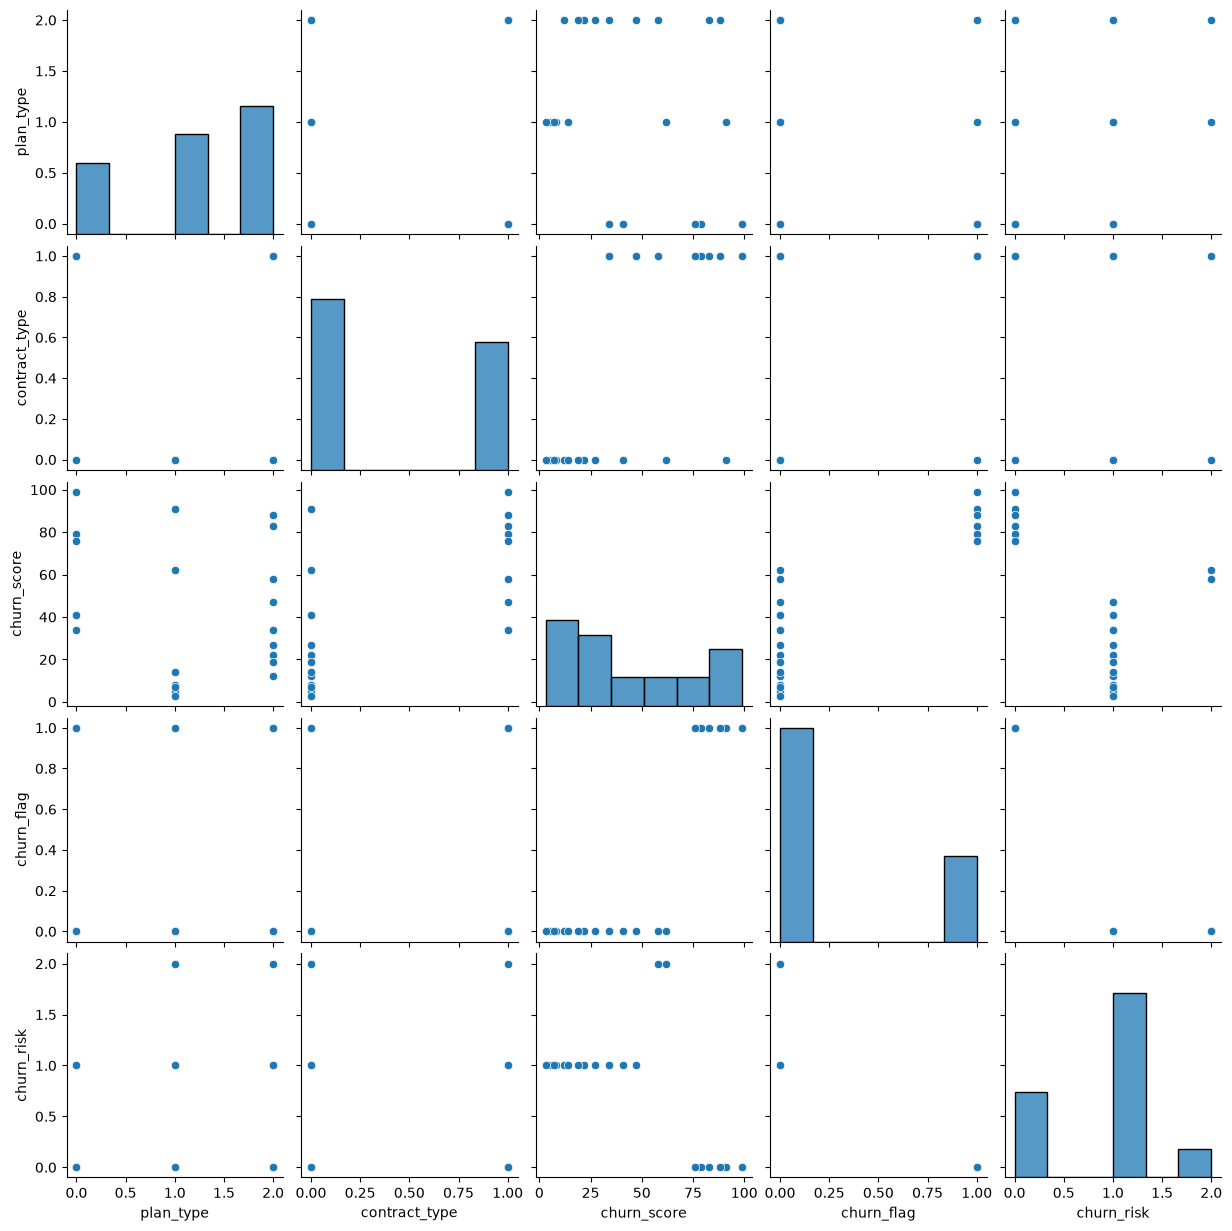

In [120]:
#pailplot
sns.pairplot(df_encoded)